In [19]:
%pip install matplotlib

  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------- -------------------------- 2.9/8.3 MB 17.0 MB/s eta 0:00:01
   ------------------ --------------------- 3.9/8.3 MB 13.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 9.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.0/8.3 MB 8.8 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.2 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 3.5 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 3.4 MB/s eta 0:00:01
   -------------------------- ------------- 1.6/2.3 MB 3.0 MB/s eta 0:00:01
   ----------------------------------- -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from pathlib import Path
import pandas as pd

project_root = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data").exists() and (candidate / "src").exists()), Path.cwd())
data_root = project_root / "data" / "raw"
videos_path = data_root / "videos" / "iphone_17_videos.parquet"
comments_path = data_root / "comments" / "iphone_17_comments.parquet"

videos = pd.read_parquet(
    videos_path
)

comments = pd.read_parquet(
    comments_path
)

print("Videos:", videos.shape)
print("Comments:", comments.shape)

Videos: (10, 12)
Comments: (764, 10)


In [13]:
print(videos.columns.tolist())
print(comments.columns.tolist())

['video_id', 'product_query', 'title', 'video_url', 'channel_name', 'published_at', 'view_count', 'like_count', 'comment_count', 'duration', 'tags', 'category_id']
['product_query', 'video_id', 'video_url', 'video_title', 'comment_id', 'author_name', 'comment_text', 'like_count', 'published_at', 'updated_at']


In [14]:
comments[["comment_text"]].sample(10)

,comment_text
268,Bro I have a iphone 15Pm and is switching to i...
94,Bro just active iphone okke safe ahno? 10k dif...
696,Just went from Iphone 14 pro to Iphone 17!!!! ...
753,Me iqoo se khush hu humko nhi chahiye iphone😂😂😂
196,Link to wallpaper plz!
12,5G ഇട്ടിട്ട് HOTSPOT ഇട്ടിട്ട് video എടുത്താ b...
7,ആപ്പിൾ ഫോണിൻ്റെ എത്ര വോൾട്ട് ചാർജർ ആണ് എടുക്കുക
695,Gooood job!
91,Nxt amazon flip big billion days sale date ari...
755,Bro iPhone 17 ka freedom sale me price Kya hog...


In [12]:
from pathlib import Path
import pandas as pd

project_root = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data").exists() and (candidate / "src").exists()), Path.cwd())
df = pd.read_parquet(
    project_root / "data" / "processed" / "comments" / "nintendo_switch_comments_processed.parquet"
)

print(df.shape)
df.head()

(1790, 16)


,product_query,video_id,video_url,video_title,comment_id,author_name,comment_text,like_count,published_at,updated_at,detected_language,cleaned_comment_text,is_empty,is_deleted,is_short_comment,is_spam
0,Nintendo Switch,EXyrGU33d90,https://www.youtube.com/watch?v=EXyrGU33d90,The Nintendo Switch 2 boot screen is everythin...,UgwAkW-hoD4l_hX2OeJ4AaABAg,@SalimataDeyman,Hello,0,2026-05-31T15:28:15Z,2026-05-31T15:28:15Z,english,hello,False,False,False,False
1,Nintendo Switch,EXyrGU33d90,https://www.youtube.com/watch?v=EXyrGU33d90,The Nintendo Switch 2 boot screen is everythin...,UgxQPdQIJ9Mrv3Nnytp4AaABAg,@SalimataDieng-oo3pc,Hello,2,2026-05-31T15:27:51Z,2026-05-31T15:27:51Z,english,hello,False,False,False,False
2,Nintendo Switch,EXyrGU33d90,https://www.youtube.com/watch?v=EXyrGU33d90,The Nintendo Switch 2 boot screen is everythin...,UgzeQvnsJ3_GEbF4szN4AaABAg,@mounirwhite5141,Is it suitable for creating YouTube streaming ...,0,2026-05-31T01:01:59Z,2026-05-31T01:01:59Z,english,is it suitable for creating youtube streaming ...,False,False,False,False
3,Nintendo Switch,EXyrGU33d90,https://www.youtube.com/watch?v=EXyrGU33d90,The Nintendo Switch 2 boot screen is everythin...,UgyKcXXR5UdJf-PuqKV4AaABAg,@h.r.gaminglist497,So satisfying 🎉,0,2026-05-30T16:41:01Z,2026-05-30T16:41:01Z,english,so satisfying 🎉,False,False,False,False
4,Nintendo Switch,EXyrGU33d90,https://www.youtube.com/watch?v=EXyrGU33d90,The Nintendo Switch 2 boot screen is everythin...,UgxI_pPLsQrYx6tnUd54AaABAg,@aliAlfara-w2k,السلام عليكم ادي حقا,0,2026-05-27T18:27:55Z,2026-05-27T18:27:55Z,unknown,السلام عليكم ادي حقا,False,False,False,False


In [13]:
new_cols = [
    "cleaned_comment_text",
    "is_empty",
    "is_deleted",
    "is_short_comment",
    "is_spam"
]

print(df[new_cols].head())

                                cleaned_comment_text  is_empty  is_deleted  \
0                                              hello     False       False   
1                                              hello     False       False   
2  is it suitable for creating youtube streaming ...     False       False   
3                                    so satisfying 🎉     False       False   
4                               السلام عليكم ادي حقا     False       False   

   is_short_comment  is_spam  
0             False    False  
1             False    False  
2             False    False  
3             False    False  
4             False    False  


In [14]:
sample = df.sample(20)

for _, row in sample.iterrows():
    print("="*80)
    print("RAW:")
    print(row["comment_text"])
    print()
    print("CLEANED:")
    print(row["cleaned_comment_text"])

RAW:
Random question, what is your favorite kirby game?

CLEANED:
random question, what is your favorite kirby game?
RAW:
1 ohhhhh 2 oh

CLEANED:
1 ohhhhh 2 oh
RAW:
Neando wich 2

CLEANED:
neando wich 2
RAW:
Australia $800 for Mario kart world with the Nintendo Switch two Justin Nintendo Switch to a $600

CLEANED:
australia $800 for mario kart world with the nintendo switch two justin nintendo switch to a $600
RAW:
Kuch din 8 month hogaya

CLEANED:
kuch din 8 month hogaya
RAW:
Ummm guys... My Nintendo Is 20K

CLEANED:
ummm guys. my nintendo is 20k
RAW:
R.I.P. Nintendo Switch (2017-2021)

CLEANED:
r.i.p. nintendo switch (2017-2021)
RAW:
Bro forgot switch lite

CLEANED:
bro forgot switch lite
RAW:
You sound like 1980sgamer

CLEANED:
you sound like 1980sgamer
RAW:
👇Team Nintendo

CLEANED:
👇team nintendo
RAW:
ISSEY ACHA TOH LENEVO LEGIO GO HAY

CLEANED:
issey acha toh lenevo legio go hay
RAW:
Selo roba el juego*

CLEANED:
selo roba el juego*
RAW:
👍

CLEANED:
👍
RAW:
Hii 
mere paas jail brea

In [15]:
keywords = ["not", "never", "no"]

for word in keywords:
    count = df["cleaned_comment_text"].str.contains(
        rf"\b{word}\b",
        case=False,
        na=False
    ).sum()

    print(word, count)

not 86
never 24
no 51


In [16]:
spam = df[df["is_spam"] == True]

print(spam.shape)
spam[["comment_text"]].sample(20)

(87, 16)


,comment_text
787,MAFIA OF PAKISTAN \n\n ARMY CHEIF...
655,😍😍👍
407,🤔😦😵🙄😧🙉
1421,Checking......... hmm its nintendo switch 1
1735,?????????????
692,🎉🎉🎉🎉🎉🎉11
682,❤
1521,🎉
205,😂😂😂😂😂😂😂😂😂🥔🥔🥔🥔🥔🥔🥔🥔🥔🥔🥔🥔🍄‍🟫
1198,🎉🎉


In [17]:
short_comments = df[df["is_short_comment"]]

short_comments[
    ["comment_text", "cleaned_comment_text"]
].sample(20)

,comment_text,cleaned_comment_text
581,1,1
1098,B,b
174,😌,😌
605,2,2
1198,🎉🎉,🎉🎉
283,❤,❤
1494,Hi,hi
225,PC,pc
600,2,2
16,😊🎉,😊🎉


In [18]:
df[
    ["comment_text", "cleaned_comment_text", "detected_language"]
].sample(20)

,comment_text,cleaned_comment_text,detected_language
696,Me gusta,me gusta,english
350,750$ switch 2,750$ switch 2,english
528,Chalti hai,chalti hai,hinglish
1035,Ever heard of inflation,ever heard of inflation,english
1259,I got a Nintendo switch,i got a nintendo switch,english
698,Nonononono,nonononono,english
513,Bhai mere pass dono hai,bhai mere pass dono hai,hinglish
1213,That’s hella outdated,that’s hella outdated,english
238,Who is watching without money 😂,who is watching without money 😂,english
1442,Elle est stylé la vidéo,elle est stylé la vidéo,english


In [19]:
raw_avg = df["comment_text"].str.len().mean()

clean_avg = df["cleaned_comment_text"].str.len().mean()

print("Raw:", raw_avg)
print("Clean:", clean_avg)

Raw: 61.04804469273743
Clean: 60.64581005586592


In [20]:
spam_examples = df[df["is_spam"]]

spam_examples[
    ["comment_text", "cleaned_comment_text"]
].head(50)

,comment_text,cleaned_comment_text
6,😮😮😮😮❤❤❤🙏🙏🙏🙏,😮😮😮😮❤❤❤🙏🙏🙏🙏
7,❤❤❤❤,❤❤❤❤
14,La quiero 😢😢😢😢😢😢😢😢😢😢😢😢,la quiero 😢😢😢😢😢😢😢😢😢😢😢😢
16,😊🎉,😊🎉
19,Giveaway please,giveaway please
58,AHHHHHHA,ahhhhhha
99,NOOOOOOOOOO NO GAME CARDS,noooooooooo no game cards
149,❤❤❤❤❤❤❤❤❤,❤❤❤❤❤❤❤❤❤
153,3:56 fahhhhhhhhhh!!!!!!!!!!!!!!!!,3:56 fahhhhhhhhhh!
169,👑👑👑. 👎👎👎👎\nMobile. ...,👑👑👑. 👎👎👎👎 mobile. psportal


## Raw CSV cleaning

Load the master raw export, reuse the project preprocessing helpers, and save a cleaned dataset for downstream analysis.

In [1]:
from pathlib import Path
import sys

import pandas as pd

project_root = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data").exists() and (candidate / "src").exists()),
    Path.cwd(),
)

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from reviewradar.preprocessing import build_preprocessing_report, preprocess_comments

raw_csv_path = project_root / "data" / "exports" / "reviewradar_master_raw.csv"
cleaned_output_path = project_root / "data" / "processed" / "reviewradar_master_cleaned.parquet"

In [2]:
raw_df = pd.read_csv(raw_csv_path)

print("Raw shape:", raw_df.shape)
print(raw_df.dtypes)
raw_df.head()

Raw shape: (4267, 20)
product_query               str
video_id                    str
video_title                 str
video_url                   str
channel_name                str
published_at                str
view_count                int64
comment_count             int64
video_like_count        float64
comment_id                  str
author_name                 str
comment_text                str
cleaned_comment_text        str
comment_like_count        int64
detected_language           str
is_empty                   bool
is_deleted                 bool
is_short_comment        float64
is_spam                    bool
updated_at                  str
dtype: object


,product_query,video_id,video_title,video_url,channel_name,published_at,view_count,comment_count,video_like_count,comment_id,author_name,comment_text,cleaned_comment_text,comment_like_count,detected_language,is_empty,is_deleted,is_short_comment,is_spam,updated_at
0,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! ...,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgwVhwRFUaLXgIZ3RSV4AaABAg,@ron0912,My first iphone was 7 and switched to android…...,my first iphone was 7 and switched to android....,0,english,False,False,NaN,False,2026-06-02T09:14:16Z
1,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! ...,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgzD7exzeovIY3aajwh4AaABAg,@BiopicBoys,bro ssd connect aavum. files angattum ingattum...,bro ssd connect aavum. files angattum ingattum...,0,english,False,False,NaN,False,2026-06-01T06:32:25Z
2,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! ...,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgyyZIRPpEvFN-yUncR4AaABAg,@cibinkoshy6164,iPhone 17 case link,iphone 17 case link,0,english,False,False,NaN,False,2026-06-01T04:34:48Z
3,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! ...,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgxK5CoEXDfjavhdoL94AaABAg,@cmsullanam007,എന്താണ് ഐഫോൺ ഫോബിസ്,എന്താണ് ഐഫോൺ ഫോബിസ്,0,malayalam,False,False,NaN,False,2026-05-29T04:00:39Z
4,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! ...,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgzOgv6yFUhr5WZPX8J4AaABAg,@Kuttu-xolo0123,Njan phone vangichu vera level 😍,njan phone vangichu vera level 😍,1,english,False,False,NaN,False,2026-05-28T01:51:01Z


In [3]:
cleaned_df = preprocess_comments(raw_df, text_column="comment_text")
report = build_preprocessing_report(cleaned_df, original_rows=len(raw_df))

print(report)
cleaned_df[["comment_text", "cleaned_comment_text", "is_empty", "is_deleted", "is_short_comment", "is_spam"]].head()

{'original_rows': 4267, 'processed_rows': 4267, 'spam_count': 159, 'empty_count': 3, 'deleted_count': 0, 'short_comment_count': 68}


,comment_text,cleaned_comment_text,is_empty,is_deleted,is_short_comment,is_spam
0,My first iphone was 7 and switched to android…...,my first iphone was 7 and switched to android....,False,False,False,False
1,bro ssd connect aavum. files angattum ingattum...,bro ssd connect aavum. files angattum ingattum...,False,False,False,False
2,iPhone 17 case link,iphone 17 case link,False,False,False,False
3,എന്താണ് ഐഫോൺ ഫോബിസ്,എന്താണ് ഐഫോൺ ഫോബിസ്,False,False,False,False
4,Njan phone vangichu vera level 😍,njan phone vangichu vera level 😍,False,False,False,False


In [ ]:
sample_columns = [
    column
    for column in ["comment_text", "cleaned_comment_text", "is_empty", "is_deleted", "is_short_comment", "is_spam"]
    if column in cleaned_df.columns
]

if sample_columns:
    print(cleaned_df[sample_columns].sample(min(10, len(cleaned_df)), random_state=42))

for column in ["is_empty", "is_deleted", "is_short_comment", "is_spam"]:
    if column in cleaned_df.columns:
        print(f"{column}: {int(cleaned_df[column].fillna(False).astype(bool).sum())}")

In [4]:
cleaned_output_path.parent.mkdir(parents=True, exist_ok=True)
cleaned_df.to_parquet(cleaned_output_path, index=False)
print(f"Saved cleaned dataset to {cleaned_output_path}")

Saved cleaned dataset to e:\VsCodeData\Projects\Review-radar\data\processed\reviewradar_master_cleaned.parquet


In [5]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [13]:
df = pd.read_csv(raw_csv_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (4267, 20)


,product_query,video_id,video_title,video_url,channel_name,published_at,view_count,comment_count,video_like_count,comment_id,author_name,comment_text,cleaned_comment_text,comment_like_count,detected_language,is_empty,is_deleted,is_short_comment,is_spam,updated_at
0,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! | Sale King !! | Malayalam,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgwVhwRFUaLXgIZ3RSV4AaABAg,@ron0912,My first iphone was 7 and switched to android…. Then im back to iphone 17 ❤,my first iphone was 7 and switched to android. then im back to iphone 17 ❤,0,english,False,False,NaN,False,2026-06-02T09:14:16Z
1,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! | Sale King !! | Malayalam,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgzD7exzeovIY3aajwh4AaABAg,@BiopicBoys,bro ssd connect aavum. files angattum ingattum maataam. blackmagic vech direct video ssd ilek record cheyyam. blackmagic cam indenkill prores access aavum.,bro ssd connect aavum. files angattum ingattum maataam. blackmagic vech direct video ssd ilek record cheyyam. blackmagic cam indenkill prores access aavum.,0,english,False,False,NaN,False,2026-06-01T06:32:25Z
2,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! | Sale King !! | Malayalam,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgyyZIRPpEvFN-yUncR4AaABAg,@cibinkoshy6164,iPhone 17 case link,iphone 17 case link,0,english,False,False,NaN,False,2026-06-01T04:34:48Z
3,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! | Sale King !! | Malayalam,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgxK5CoEXDfjavhdoL94AaABAg,@cmsullanam007,എന്താണ് ഐഫോൺ ഫോബിസ്,എന്താണ് ഐഫോൺ ഫോബിസ്,0,malayalam,False,False,NaN,False,2026-05-29T04:00:39Z
4,Iphone 17,slOtZZmLX0I,iPhone 17 | My Review | Best iPhone Evaaa !!! | Sale King !! | Malayalam,https://www.youtube.com/watch?v=slOtZZmLX0I,CallMeShazzam TECH,2025-11-07T08:57:56Z,627809,872,18788.0,UgzOgv6yFUhr5WZPX8J4AaABAg,@Kuttu-xolo0123,Njan phone vangichu vera level 😍,njan phone vangichu vera level 😍,1,english,False,False,NaN,False,2026-05-28T01:51:01Z


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:\n")
print(df.columns.tolist())

Rows: 4267
Columns: 20

Column Names:

['product_query', 'video_id', 'video_title', 'video_url', 'channel_name', 'published_at', 'view_count', 'comment_count', 'video_like_count', 'comment_id', 'author_name', 'comment_text', 'cleaned_comment_text', 'comment_like_count', 'detected_language', 'is_empty', 'is_deleted', 'is_short_comment', 'is_spam', 'updated_at']


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4267 entries, 0 to 4266
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_query         4267 non-null   str    
 1   video_id              4267 non-null   str    
 2   video_title           4267 non-null   str    
 3   video_url             4267 non-null   str    
 4   channel_name          4267 non-null   str    
 5   published_at          4267 non-null   str    
 6   view_count            4267 non-null   int64  
 7   comment_count         4267 non-null   int64  
 8   video_like_count      4242 non-null   float64
 9   comment_id            4267 non-null   str    
 10  author_name           4267 non-null   str    
 11  comment_text          4264 non-null   str    
 12  cleaned_comment_text  4262 non-null   str    
 13  comment_like_count    4267 non-null   int64  
 14  detected_language     4267 non-null   str    
 15  is_empty              4267 non-n

In [16]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

is_short_comment        4267
video_like_count          25
cleaned_comment_text       5
comment_text               3
dtype: int64

In [17]:
df["detected_language"].value_counts()

detected_language
english                    3842
hinglish                    237
unknown                     156
mixed_malayalam_english       7
romanized_malayalam           6
tamil                         5
malayalam                     4
kannada                       4
mixed_kannada_english         3
mixed_tamil_english           2
gujarati                      1
Name: count, dtype: int64

<Axes: xlabel='detected_language'>

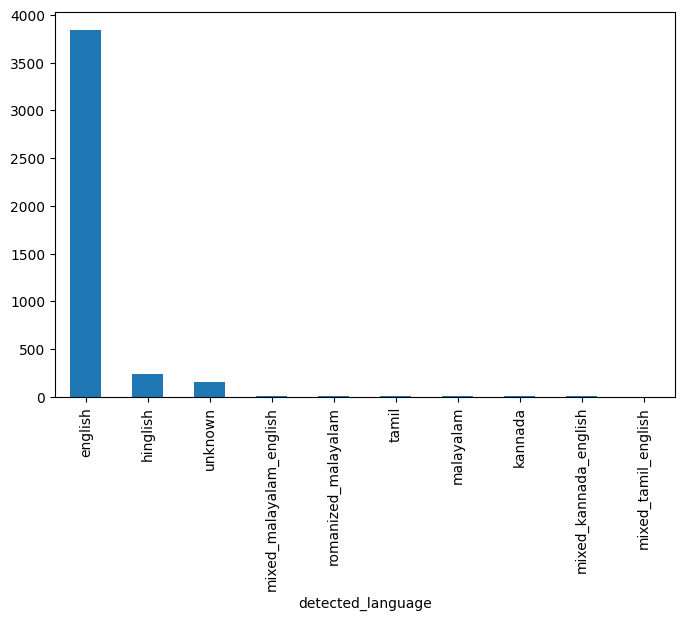

In [20]:
(
    df["detected_language"]
    .value_counts()
    .head(10)
    .plot(kind="bar", figsize=(8,5))
)

In [21]:
df["is_spam"].value_counts()

is_spam
False    4108
True      159
Name: count, dtype: int64

In [22]:
spam_pct = (
    df["is_spam"].mean() * 100
)

print(f"Spam Percentage: {spam_pct:.2f}%")

Spam Percentage: 3.73%


In [23]:
eda_df = df.copy()

eda_df = eda_df[
    eda_df["is_spam"] == False
]

eda_df = eda_df[
    eda_df["is_empty"] == False
]

eda_df = eda_df[
    eda_df["cleaned_comment_text"].notna()
]

print(eda_df.shape)

(4103, 20)


In [24]:
eda_df["comment_length"] = (
    eda_df["cleaned_comment_text"]
    .fillna("")
    .str.len()
)

eda_df["comment_length"].describe()

count    4103.000000
mean       97.876919
std       176.870952
min         1.000000
25%        25.000000
50%        49.000000
75%       105.000000
max      5664.000000
Name: comment_length, dtype: float64

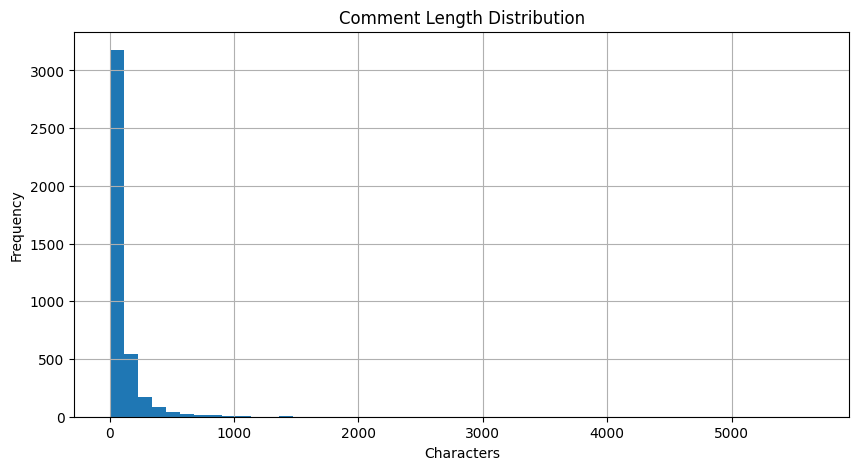

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

eda_df["comment_length"].hist(
    bins=50
)

plt.title("Comment Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [26]:
eda_df.sort_values(
    "comment_like_count",
    ascending=False
)[
    [
        "product_query",
        "comment_text",
        "comment_like_count"
    ]
].head(20)

,product_query,comment_text,comment_like_count
1505,Nintendo Switch,Nintendo needs to get cooking with these first party games...but if they do...🤩\nTo see me test the most futuristic TRANSPARENT Tech: https://youtu.be/fepKQej1DH0,810
2602,Steam Deck,"""click THIS option"" shows screen at a diabolically stupid angle.",627
2617,Steam Deck,I didn’t even know the steam deck was real,380
2625,Steam Deck,"Yeah, well, what does it mean?",287
728,Iphone 17,"I just upgraded 3 days ago, from iPhone 11 (64GB) to iPhone 17 (256GB). The big increase of storage is the best part lol. And yeah, i love every bit of iPhone 17. Gonna embrace it for the next.. 6...",273
905,Nintendo Switch,Mobiles Best !,256
1704,Nintendo Switch,Last batch of SwitchIt cards with 60% OFF in the link in our profile!!! 🚨🎮,240
1700,Nintendo Switch,Imma wait til there’s an OLED switch 2 model and when physical games start appearing in 2nd hand stores,212
1491,Nintendo Switch,"Bro this switch 2 is premium when I get it in my hands, I’ll take care of it",184
2354,Nintendo Switch,click the related video for 5 great games to play on your Nintendo Switch!,181


In [27]:
eda_df["product_query"].value_counts()

product_query
Nintendo Switch    1700
Steam Deck         1664
Iphone 17           739
Name: count, dtype: int64

In [28]:
eda_df.groupby(
    "channel_name"
).size().sort_values(
    ascending=False
).head(20)

channel_name
EmSwizzle              290
Venom's Tech           284
Marques Brownlee       199
Garrett Crespo         196
Dominic Malta          188
Created Tech           100
Beebom                 100
Nick Flip               99
Austin Evans            99
TechLinked              99
The WAN Show            99
SwitchIt                99
Paper Tay               98
Nintendo of America     98
ShoAndTech              98
Mrwhosetheboss          98
CallMeShazzam TECH      98
Life of Shubh           98
Dave2D                  97
More1980sGamer          97
dtype: int64

In [29]:
eda_df.sort_values(
    "comment_length",
    ascending=False
)[
    [
        "product_query",
        "channel_name",
        "comment_length",
        "comment_text"
    ]
].head(10)

,product_query,channel_name,comment_length,comment_text
3303,Steam Deck,The Comic Book Gamer,5664,"Switch 2 is already my favorite handheld ever but I don’t believe it’s that much better than a Steam Deck. For Nintendorks who trashes the Steam Deck on Reddit or wherever, it’s because they never..."
2956,Steam Deck,Venom's Tech,2960,Timestamps \n00:03 - Steam Deck offers great value for gaming in 2025.\n00:42 - Unboxing highlights of the Steam Deck OLED's packaging.\n02:07 - Steam Deck 2025 features enhanced RAM and improved ...
413,Iphone 17,Tech in Kannada,2371,"Main Difference between iphone 16 and 17 \nDesign and Build\nBoth models share a nearly identical aluminum frame and flat-edged glass design, with the same 0.31-inch thickness and vertical pill-sh..."
511,Iphone 17,Carter Nolan,2199,Excellent review really enjoyed it. \nSo your videos from the first time you got the iPhone 17. \n\nComing from a 14 pro.\nReally wanted to get the iPhone 17 Air for the lightness and new design. ...
3998,Steam Deck,Garrett Crespo,2063,This is a completely disingenuous review really only trying to spread the gospel of the cult of gabism than an actual review to help the normal person make a buying decision. The oled screen at a...
1752,Nintendo Switch,SwitchIt,1466,"""heres why ill never upgrade to a switch 2- PIRATING! :D"" yeah no im good on that buddy, do you realize nintendo is a lifetime game investment? my 8 pokemon games on the DS got me a switch 2 for f..."
3683,Steam Deck,Austin Evans,1454,"I have had the LCD Steamdeck since almost launch, and decided to get the OLED just last Christmas (had no idea they would be so hard to get just 3 months later). Since the purchase ofbthe LCD mod..."
3583,Steam Deck,TechLinked,1423,"How do AI plate readers protect the kids? It doesn't prevent cars from passing the bus, it only fines them. Oh because the person willing to chance passing the bus will have to pay, after they a..."
3431,Steam Deck,Garrett Crespo,1260,steam-deck is my great filter. If I cant play it i don't want to. Slimetendo doesn't put out good content anymore and actively tries to snuff out other game companies. Activation and UbiSoft put o...
2034,Nintendo Switch,Marques Brownlee,1127,I haven't owned a Nintendo console since the 3DS. I've been on PS and Xbox since. I just traded my Xbox Series X in for a Switch 2. \nSo far this is the best console I have bought since a PSP and ...


In [30]:
eda_df.sort_values(
    "comment_like_count",
    ascending=False
)[
    [
        "product_query",
        "comment_like_count",
        "comment_text"
    ]
].head(20)

,product_query,comment_like_count,comment_text
1505,Nintendo Switch,810,Nintendo needs to get cooking with these first party games...but if they do...🤩\nTo see me test the most futuristic TRANSPARENT Tech: https://youtu.be/fepKQej1DH0
2602,Steam Deck,627,"""click THIS option"" shows screen at a diabolically stupid angle."
2617,Steam Deck,380,I didn’t even know the steam deck was real
2625,Steam Deck,287,"Yeah, well, what does it mean?"
728,Iphone 17,273,"I just upgraded 3 days ago, from iPhone 11 (64GB) to iPhone 17 (256GB). The big increase of storage is the best part lol. And yeah, i love every bit of iPhone 17. Gonna embrace it for the next.. 6..."
905,Nintendo Switch,256,Mobiles Best !
1704,Nintendo Switch,240,Last batch of SwitchIt cards with 60% OFF in the link in our profile!!! 🚨🎮
1700,Nintendo Switch,212,Imma wait til there’s an OLED switch 2 model and when physical games start appearing in 2nd hand stores
1491,Nintendo Switch,184,"Bro this switch 2 is premium when I get it in my hands, I’ll take care of it"
2354,Nintendo Switch,181,click the related video for 5 great games to play on your Nintendo Switch!


In [31]:
eda_df["comment_like_count"].describe()

count    4103.000000
mean        1.845723
std        20.853891
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       810.000000
Name: comment_like_count, dtype: float64

In [32]:
(
    eda_df["comment_like_count"]
    .value_counts()
    .head(20)
)

comment_like_count
0     3200
1      536
2      146
3       63
4       32
5       15
6       14
7       11
8        9
11       5
20       4
9        4
18       4
10       4
14       3
15       3
27       2
23       2
70       2
26       2
Name: count, dtype: int64

In [36]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- --------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

text = eda_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=50
)

X = vectorizer.fit_transform(text)

word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(
    "count",
    ascending=False
)

word_counts.head(30)

,word,count
40,switch,950
39,steam,681
10,deck,615
13,games,449
29,nintendo,444
23,just,407
24,like,352
0,17,348
22,iphone,318
34,play,242


In [38]:
switch_df = eda_df[
    eda_df["product_query"] == "Nintendo Switch"
]

text = switch_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform(text)

switch_words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

switch_words.sort_values(
    "count",
    ascending=False
).head(20)

,word,count
27,switch,748
20,nintendo,377
9,games,160
16,like,107
21,oled,96
14,just,89
25,ps5,82
13,hai,82
23,play,78
5,console,77


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

text = eda_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=50
)

X = vectorizer.fit_transform(text)

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

bigrams = bigrams.sort_values(
    "count",
    ascending=False
)

bigrams.head(30)

,bigram,count
34,steam deck,496
26,nintendo switch,226
18,iphone 17,153
33,rog ally,49
32,pro max,45
7,deck oled,42
44,switch oled,39
1,17 pro,37
42,switch lite,35
4,battery life,33


In [40]:
switch_df = eda_df[
    eda_df["product_query"] == "Nintendo Switch"
]

text = switch_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=30
)

X = vectorizer.fit_transform(text)

switch_bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

switch_bigrams.sort_values(
    "count",
    ascending=False
).head(20)

,bigram,count
15,nintendo switch,209
28,switch oled,35
21,steam deck,31
26,switch lite,30
12,mario kart,18
23,switch games,16
29,switch switch,13
14,nintendo games,13
27,switch nintendo,12
8,getting switch,12


In [42]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

custom_stopwords = [
    "steam",
    "deck",
    "switch",
    "nintendo",
    "iphone",
    "17",
    "16",
    "pro",
    "max"
]

text = eda_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=50
)

X = vectorizer.fit_transform(text)

words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

words = words[
    ~words["word"].isin(custom_stopwords)
]

words.sort_values(
    "count",
    ascending=False
).head(30)

,word,count
13,games,449
23,just,407
24,like,352
34,play,242
35,price,232
30,oled,231
12,game,205
4,better,202
46,video,196
31,pc,193


In [43]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

text = eda_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3,3),
    max_features=50
)

X = vectorizer.fit_transform(text)

trigrams = pd.DataFrame({
    "trigram": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

trigrams.sort_values(
    "count",
    ascending=False
).head(30)

,trigram,count
38,steam deck oled,39
49,watching iphone 17,18
37,steam deck offers,16
11,games steam deck,12
3,17 pro max,12
7,buy steam deck,11
19,love steam deck,10
24,nintendo switch oled,9
4,asus rog ally,8
6,bought steam deck,8


In [45]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

custom_stopwords = {
    "steam","deck","switch","nintendo","iphone",
    "17","16","15","14","pro","max",
    "just","like","bro","got","buy",
    "video","people","new","best"
}

text = eda_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    max_features=200
)

X = vectorizer.fit_transform(text)

feature_words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

feature_words.sort_values(
    "count",
    ascending=False
).head(50)

,word,count
153,the,2906
165,to,1478
13,and,1475
80,it,1416
79,is,1179
52,for,875
112,on,770
109,of,740
198,you,702
102,my,700


In [46]:
switch_df = eda_df[
    eda_df["product_query"] == "Nintendo Switch"
]

text = switch_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    max_features=100
)

X = vectorizer.fit_transform(text)

switch_features = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

switch_features.sort_values(
    "count",
    ascending=False
).head(30)

,word,count
79,the,719
5,and,350
41,it,331
40,is,326
85,to,322
98,you,211
53,my,204
22,for,202
78,that,180
34,have,175


In [47]:
steam_df = eda_df[
    eda_df["product_query"] == "Steam Deck"
]

text = steam_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    max_features=100
)

X = vectorizer.fit_transform(text)

steam_features = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

steam_features.sort_values(
    "count",
    ascending=False
).head(30)

,word,count
72,the,1626
40,it,877
81,to,855
6,and,851
39,is,652
21,for,533
52,of,481
54,on,469
71,that,423
98,you,391


In [48]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import pandas as pd

custom_stopwords = {
    "steam","deck","switch","nintendo",
    "iphone","17","16","15","14",
    "pro","max",
    "bro","just","got","like",
    "video","videos"
}

all_stopwords = ENGLISH_STOP_WORDS.union(custom_stopwords)

text = eda_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words=list(all_stopwords),
    max_features=100
)

X = vectorizer.fit_transform(text)

word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

word_freq.sort_values(
    "count",
    ascending=False
).head(50)

,word,count
27,games,449
63,play,242
66,price,232
58,oled,231
26,game,205
10,better,202
59,pc,193
14,buy,187
23,don,187
85,use,168


In [49]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

switch_df = eda_df[
    eda_df["product_query"] == "Nintendo Switch"
]

all_stopwords = ENGLISH_STOP_WORDS.union(custom_stopwords)

text = switch_df["cleaned_comment_text"].fillna("")

vectorizer = CountVectorizer(
    stop_words=list(all_stopwords),
    max_features=100
)

X = vectorizer.fit_transform(text)

switch_words = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

switch_words.sort_values(
    "count",
    ascending=False
).head(30)

,word,count
27,games,160
62,oled,96
74,ps5,82
34,hai,82
66,play,78
14,console,77
26,game,72
54,mario,64
12,buy,63
7,better,56


In [50]:
feature_keywords = {
    "Display": [
        "oled",
        "screen",
        "display"
    ],

    "Price": [
        "price",
        "expensive",
        "cheap",
        "cost"
    ],

    "Gaming": [
        "games",
        "game",
        "mario",
        "gta"
    ],

    "Competition": [
        "ps5",
        "xbox",
        "pc"
    ],

    "Purchase Intent": [
        "buy",
        "want",
        "getting"
    ]
}

for feature, words in feature_keywords.items():
    count = 0

    for word in words:
        count += (
            switch_df["cleaned_comment_text"]
            .str.contains(
                rf"\b{word}\b",
                case=False,
                na=False
            )
            .sum()
        )

    print(f"{feature}: {count}")

Display: 120
Price: 62
Gaming: 273
Competition: 117
Purchase Intent: 126


In [51]:
positive_words = [
    "good",
    "great",
    "best",
    "love",
    "amazing",
    "awesome",
    "excellent"
]

negative_words = [
    "bad",
    "worst",
    "hate",
    "expensive",
    "poor",
    "issue",
    "problem"
]

for aspect, keywords in feature_keywords.items():

    aspect_comments = switch_df[
        switch_df["cleaned_comment_text"]
        .str.contains(
            "|".join(keywords),
            case=False,
            na=False
        )
    ]

    positive = 0
    negative = 0

    for text in aspect_comments["cleaned_comment_text"]:

        text = str(text).lower()

        if any(word in text for word in positive_words):
            positive += 1

        if any(word in text for word in negative_words):
            negative += 1

    print("\n", aspect)
    print("Positive:", positive)
    print("Negative:", negative)


 Display
Positive: 15
Negative: 5

 Price
Positive: 8
Negative: 15

 Gaming
Positive: 36
Negative: 11

 Competition
Positive: 20
Negative: 8

 Purchase Intent
Positive: 21
Negative: 8


In [52]:
products = eda_df["product_query"].unique()

print(products)

<ArrowStringArray>
['Iphone 17', 'Nintendo Switch', 'Steam Deck']
Length: 3, dtype: str


In [53]:
steam_df = eda_df[
    eda_df["product_query"] == "Steam Deck"
]

In [54]:
steam_features = {
    "Display": ["oled","screen","display"],
    "Performance": ["fps","performance","gaming","pc"],
    "Price": ["price","expensive","cheap","cost"],
    "Competition": ["rog","ally","switch","console"],
    "Purchase Intent": ["buy","want","getting"]
}

In [55]:
iphone_features = {
    "Battery": ["battery","charge","charging"],
    "Camera": ["camera","photo","photos","video"],
    "Display": ["screen","display","oled"],
    "Price": ["price","expensive","cost"],
    "Purchase Intent": ["buy","want","getting"]
}

In [58]:
%pip install vaderSentiment

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl (159 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached certifi-2026.5.20-py3-none-any.whl (134 kB)

   ------ --------------------------------- 1/6 [idna]
   --------------------------------- ------ 5/6 [vaderSentiment]
   ---------------------------------------- 6/6 [vaderSentiment]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [61]:
sample_df = eda_df.sample(300, random_state=42)

In [62]:
sample_df.to_csv(
    "manual_review_sample.csv",
    index=False
)